# Lecture 1 — Introduction to Explainable Artificial Intelligence (XAI) and Its Taxonomy


## Learning Objectives

By the end of this lecture, you should be able to:

- explain why model understanding may matter beyond predictive performance;
- identify settings where explainability is particularly relevant;
- distinguish **interpretability** from **explainability**;
- distinguish **intrinsic vs. post-hoc**, **global vs. local**, and **model-specific vs. model-agnostic** approaches;
- identify stakeholders who may require different explanations;
- explain why explanation does not automatically imply causality, fairness, robustness, safety, or trustworthiness;
- connect the concepts to the accompanying Python exercise notebooks.


# 1. From machine learning to model understanding

Traditional machine-learning evaluation often emphasizes **predictive performance**.

Common metrics include:

- accuracy;
- F1 score;
- ROC-AUC;
- prediction error.

These metrics tell us how well a model performs on a given evaluation dataset.

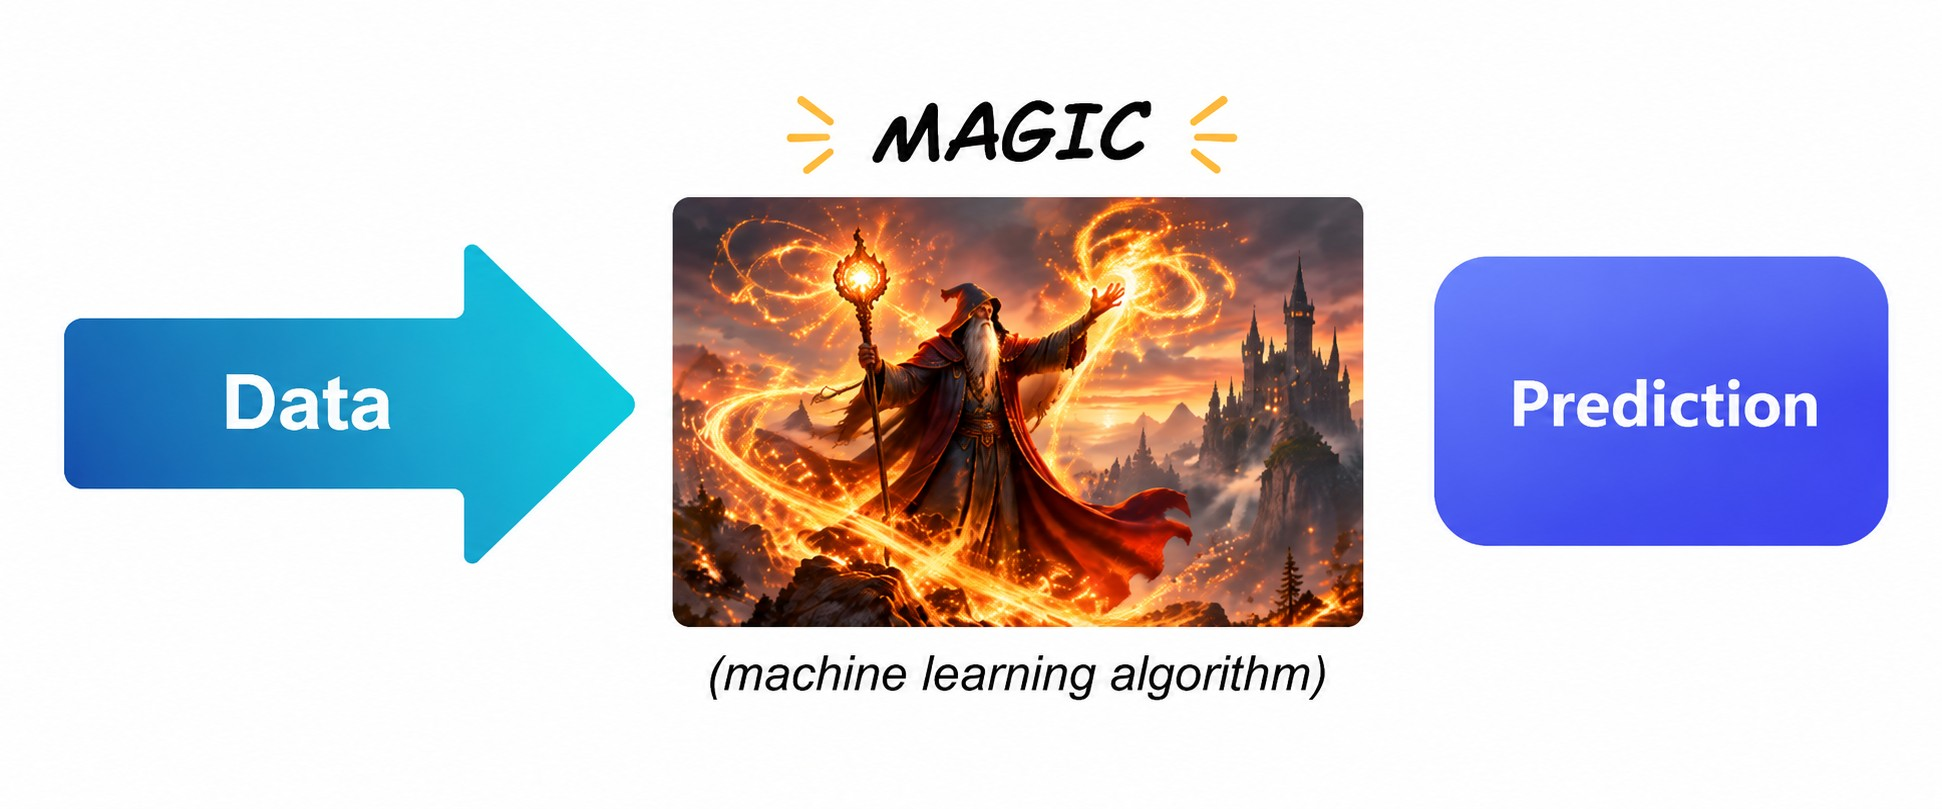

However, many modern machine-learning models can be difficult to interpret directly, especially when they contain large numbers of parameters, layers, trees, or interacting components.

Examples include:

- Random Forests;
- Gradient Boosting models;
- deep neural networks;
- convolutional neural networks (CNNs);
- Transformers.

The degree of interpretability depends not only on the model family, but also on the size and complexity of the particular model.

These models can achieve strong predictive performance, while their internal decision process may still be difficult for humans to understand directly.

This is often referred to as the **black-box problem**.

A **black-box model** is a model whose internal decision process is difficult to inspect or interpret directly.

We may observe:

**Input → Model → Prediction**

but still not clearly understand:

- Why did the model make this prediction?
- Which features influenced the result?
- Which patterns did the model rely on?
- Is the model relying on meaningful or potentially spurious information?

For example:

**Medical image → Deep neural network → Prediction: Malignant**

The model may produce a highly accurate prediction, but a clinician may still want to know:

- Which regions of the image influenced the prediction?
- Is the model using clinically meaningful information?
- Is it relying on an artefact or irrelevant background information?

The black-box nature of a model is not automatically a problem in every application.

However, it can become important when:

- decisions affect people;
- errors have serious consequences;
- models are deployed in unfamiliar environments;
- fairness or safety matters;
- users need to justify or review decisions;
- researchers want to investigate what the model has learned.

A model can therefore be **highly accurate** while still being **difficult to understand**.

This creates an important gap between:

**Predictive performance**

and

**Model understanding**

Traditional machine learning mainly asks:

> **What does the model predict?**

Explainable Artificial Intelligence (XAI) adds questions such as:

> **What information appears relevant to this prediction?**

> **What information influenced the model?**

> **Does the model appear to rely on meaningful or suspicious signals?**

> **Can we identify potential failure modes?**

> **Should a human rely on this prediction in this context?**

The transition can be summarized as:

**Traditional machine learning**

**Data → Model → Prediction**

while XAI adds another layer:

**Data → Model → Prediction → Explanation / Model understanding**

Predictive performance and model understanding answer different questions.

**Predictive performance asks:**

> How well does the model predict on the evaluated data?

**Model understanding asks:**

> How does the model produce its predictions, and what information appears to influence them?

This gap between **prediction** and **understanding** is one of the main motivations for Explainable Artificial Intelligence (XAI).

# 2. Is model understanding necessary everywhere?

Not every machine-learning application requires the same level of model understanding.

For some relatively **lower-consequence applications**, detailed model understanding may be less critical.

Examples may include:

- movie or music recommendations;
- ordinary product recommendations;
- some advertisement-ranking systems;
- some personalization systems.

In such settings, an incorrect individual prediction may have relatively limited consequences.

However, these application categories are not inherently low-stakes. Their consequences depend on the **specific use case, affected users, and how the model output is used**.

## 2.1 High-stakes applications

The situation changes when machine learning is used in **high-stakes decision-making settings**.

Model understanding can become particularly important when model outputs influence decisions that may have serious consequences for:

- **human health**;
- **personal finances**;
- **legal or administrative outcomes**;
- **safety**;
- **access to important services or opportunities**.

Examples include:

- **Healthcare**  
  Diagnosis, treatment support, and patient risk prediction.

- **Finance**  
  Loan approval, credit scoring, and fraud detection.

- **Legal / administrative systems**  
  Risk assessment and eligibility decisions.

- **Autonomous systems**  
  Self-driving vehicles and robotics.

- **Critical infrastructure**  
  Energy systems, industrial control, and safety monitoring.

These domains are not automatically high-stakes in every use case.

The stakes depend on the **specific decision, how the model is used, who may be affected, and the consequences of errors**.

In high-stakes settings, knowing only the final prediction may therefore not be enough.

Users may also need to investigate:

> Why did the model make this prediction?

> Which information influenced the prediction?

> Is the model relying on meaningful or potentially problematic information?

> Does the model behave reliably and appropriately in the intended context?

## 2.2 Why high-stakes settings need more scrutiny

There are several reasons.

### 2.2.1 Decisions can have serious consequences

Errors in different applications can have very different consequences.

For example:

**Wrong movie recommendation**  
→ Usually a small inconvenience

**Wrong medical diagnosis**  
→ Potentially serious harm

Similarly:

**Wrong product recommendation**  
→ The user may simply ignore it

**Wrong loan decision**  
→ A person may incorrectly lose access to credit or receive an inappropriate decision

The **consequences of failure** can therefore differ substantially across applications.

### 2.2.2 Models may not be extensively validated under all deployment conditions

A model may perform well on training and testing datasets but later encounter conditions that were not well represented during development.

Examples include:

- new patient populations;
- different sensors;
- unusual weather conditions;
- changing environments;
- previously unseen situations;
- shifts in the data distribution.

High test-set performance does not guarantee that a model will behave reliably after deployment.

This is especially important when a system operates in complex or changing environments where it is difficult to anticipate every possible deployment condition in advance.

Model understanding can help investigate whether the model relies on patterns that may become unreliable when these conditions change.

## 2.2.3 Important criteria can be difficult to capture completely

In high-stakes systems, we often care about more than predictive performance.

Important considerations may include:

- safety;
- fairness and non-discrimination;
- reliability;
- robustness;
- appropriate human oversight;
- consistency with relevant domain knowledge or requirements.

Some of these properties cannot be captured completely by a single quantitative metric.

For example, in an autonomous-driving system, it is unrealistic to enumerate and test every possible combination of:

- road conditions;
- weather;
- obstacles;
- unusual traffic behaviour;
- sensor failures.

Model understanding can therefore provide **additional evidence** about model behaviour that may not be captured by standard predictive-performance metrics alone.

However, explanations should **complement rather than replace** other forms of evaluation, such as validation, robustness testing, subgroup analysis, safety assessment, and deployment monitoring.

## 2.3 Incompleteness in problem formulation

Another challenge is that a real-world problem may not be fully captured by the objective function, dataset, model assumptions, or evaluation metrics used during development.

One useful way to describe this is **incompleteness in problem formulation**.

For example, a model may be optimized primarily for predictive performance while other important considerations, such as safety, fairness, or operational constraints, are only partially represented in the optimization objective or evaluation process.

This is different from **uncertainty**.

**Uncertainty** concerns limited knowledge or variability within a specified problem formulation, for example uncertainty about:

- model parameters;
- predictions;
- measurements;
- future outcomes.

**Incompleteness** means that some relevant aspects of the real-world problem may not have been represented in the formulation at all.

For example, an evaluation metric may measure predictive accuracy while failing to represent an important safety requirement.

This makes model evaluation more difficult because a high score on the chosen metric does not necessarily capture every property that matters in the real-world application.

Model understanding can help reveal some of these gaps, although it cannot by itself guarantee that the problem formulation is complete.

## 2.4 Simple comparison

| Lower-consequence application | High-stakes application |
|---|---|
| Movie recommendation | Medical diagnosis |
| Ordinary product recommendation | Loan approval |
| Music recommendation | Autonomous driving |
| Some advertisement ranking | Legal decision support |
| Errors may be inconvenient | Errors may have serious consequences |

Not every application requires the same level of explanation or model understanding.

**Lower-consequence application**  
→ Detailed explanation may be less critical.

**High-stakes application**  
→ Model understanding and broader evaluation become much more important.

The question is therefore not only:

> **How well does the model predict on the evaluation data?**

but also:

> **Is the model behaving appropriately for its intended context, and do we have sufficient evidence to support its use?**

# 3. Why accuracy alone may be insufficient

A model can perform strongly on a held-out test set while still **exhibiting problematic behaviour**.

This can happen for several reasons, including:

- distribution shift;
- shortcut learning;
- spurious correlations;
- subgroup-specific failures;
- sensor or environment changes;
- measurement artefacts;
- deployment conditions that differ from development conditions.

A model may therefore achieve high predictive performance during development but still perform poorly when deployed under new or changing real-world conditions.

This is important because training and test datasets cannot represent every situation that a model may encounter after deployment.

Predictive performance tells us **how well the model performs on the evaluated data**, but it does not necessarily tell us:

- which information the model is relying on;
- whether the model has learned intended or potentially fragile patterns;
- whether the same behaviour will persist when conditions change;
- whether performance is consistent across relevant subgroups;
- whether properties such as fairness, robustness, or safety are satisfied.

Model understanding can therefore complement predictive evaluation by helping us investigate **what information and patterns influence the model's predictions**.

## 3.1 Example — Shortcut learning

Suppose an image classifier achieves **95% accuracy on a held-out test set**.

At first, this appears to indicate strong predictive performance.

However, imagine that the training data contain a strong correlation between dog breed and background:

    snow → husky
    grass → labrador

The model may learn to rely heavily on the **background** rather than on features of the dog that are more directly relevant to the intended classification task.

If similar background correlations are also present in the held-out test set, the model may still achieve high test accuracy.

Now consider deployment examples such as:

    husky on grass
    labrador in snow

The background correlation has changed.

If the model relied strongly on that shortcut, its predictions may become less reliable.

This is an example of **shortcut learning**.

Shortcut learning occurs when a model relies on an easy predictive pattern that performs well on the available data but may not correspond to the intended decision rule or remain reliable when conditions change.

> **High test performance does not guarantee that the model learned the pattern we intended it to learn.**

An explanation method may help reveal such behaviour, but the explanation itself should be treated as **evidence for further investigation**, not as definitive proof that the model is wrong.

## 3.2 What does predictive performance tell us?

Metrics such as accuracy, F1 score, ROC-AUC, or prediction error summarize model performance on a particular evaluation dataset.

They answer questions such as:

> **How well does the model predict on these evaluated examples?**

They do not, by themselves, tell us:

> **Which features or patterns does the model rely on?**

> **Would the same strategy remain reliable under different conditions?**

> **Does the model perform equally well for all relevant subgroups?**

> **Is the model relying on information that is appropriate for the intended task?**

Two models can therefore achieve similar predictive performance while relying on very different patterns.

For example:

**Model A**  
→ relies mainly on features of the dog itself.

**Model B**  
→ relies heavily on background snow or grass.

Both models might perform similarly on the original test set if the same correlations are present there.

Their behaviour may differ substantially when the deployment environment changes.

## 3.3 Performance under real-world conditions

A held-out test set provides important evidence about model performance, but it only evaluates the model under the conditions represented by that dataset.

After deployment, a model may encounter:

- different populations;
- different sensors or measurement systems;
- changing environmental conditions;
- rare or unusual events;
- changes in data collection procedures;
- shifts in the relationship between inputs and outcomes.

These changes may lead to **distribution shift** and reduced model performance.

> **Strong test-set performance does not guarantee strong performance under every future deployment condition.**

This does not make test-set evaluation unimportant.

Rather, it means that test-set performance should be considered together with other forms of evaluation, such as:

- robustness testing;
- subgroup analysis;
- external validation;
- deployment monitoring;
- model-understanding techniques.

## 3.4 Predictive performance is not the only property that may matter

In many applications, especially high-stakes ones, predictive performance is only one part of model evaluation.

We may also care about:

- robustness;
- reliability;
- fairness and non-discrimination;
- safety;
- appropriate human oversight;
- consistency with relevant domain knowledge or requirements.

A model can achieve strong overall predictive performance while still having problems in one or more of these areas.

For example, a model may have high overall accuracy while performing substantially worse for a particular subgroup.

Similarly, a model may perform well under normal conditions while failing under sensor changes or unusual environmental conditions.

Model understanding can help investigate these behaviours, but it does not replace dedicated evaluation of fairness, robustness, safety, or reliability.

Predictive evaluation and model understanding therefore answer **different but complementary questions**.

**Predictive evaluation**

> How well does the model perform on the evaluated data?

**Model understanding**

> What information and patterns appear to influence the model's behaviour?

Both perspectives can be important when assessing whether a model is suitable for its intended use.

# 4. Why explain models?

Model explanations can serve several purposes beyond simply describing a prediction.

They can help us:

- identify suspicious model behaviour;
- investigate possible sources of bias;
- provide information about possible recourse;
- support human oversight and decision-making.

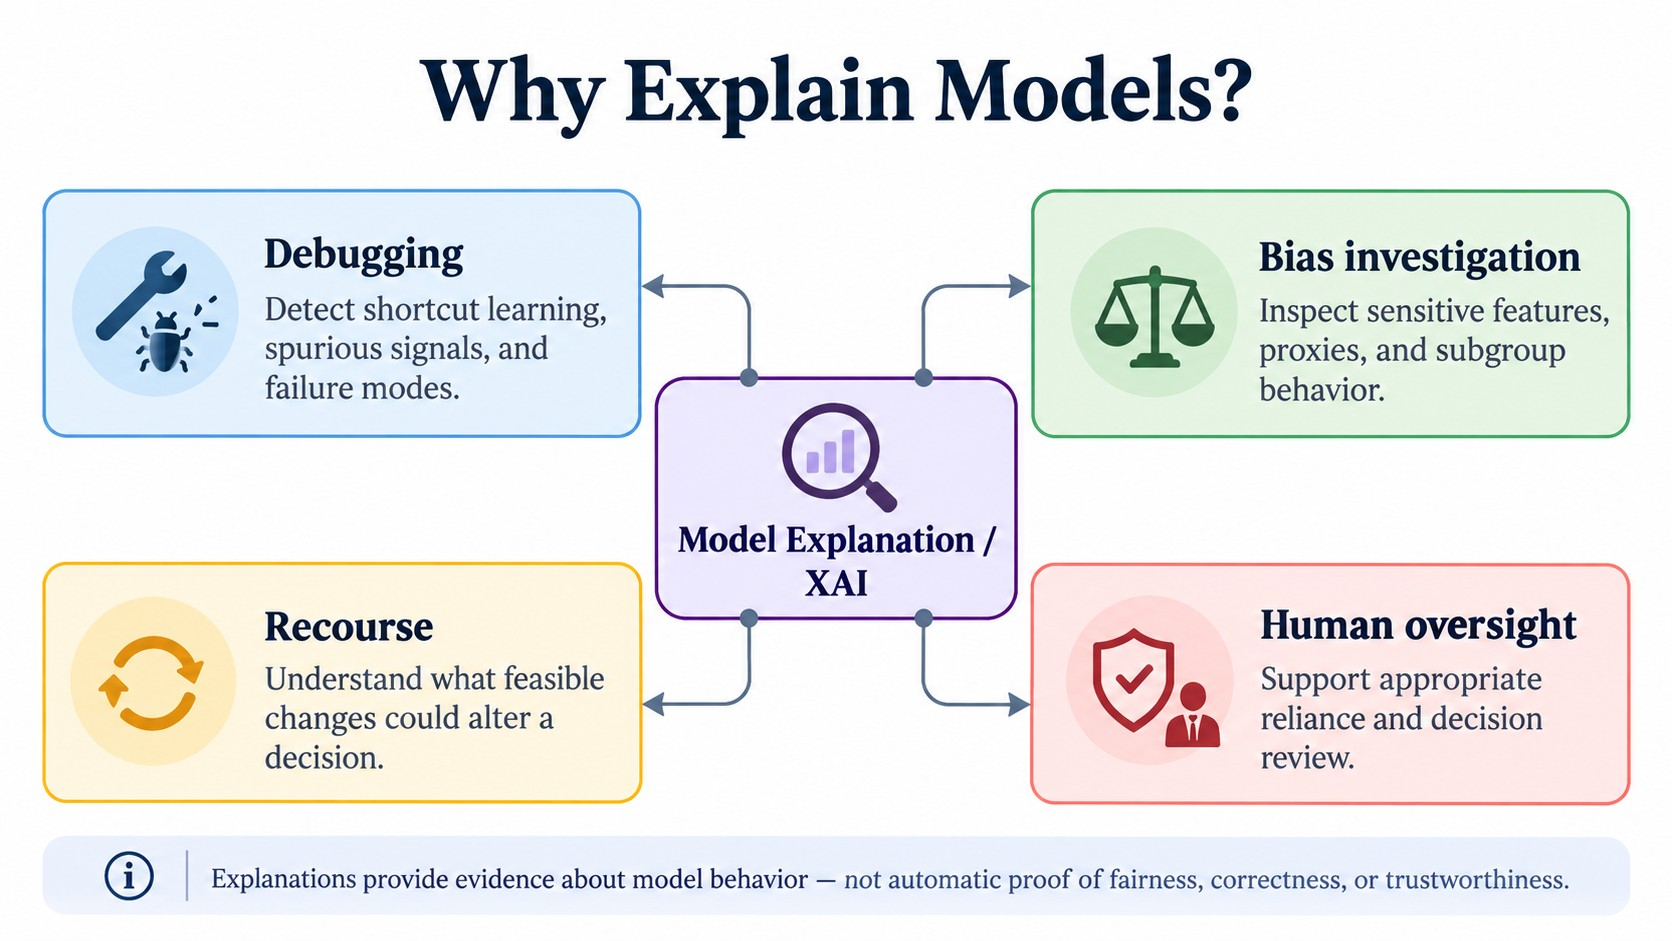

## 4.1 Debugging

Explanations can help identify cases where a model appears to rely on **irrelevant, unintended, or spurious features**.

For example, an image classifier may correctly predict:

**Siberian Husky**

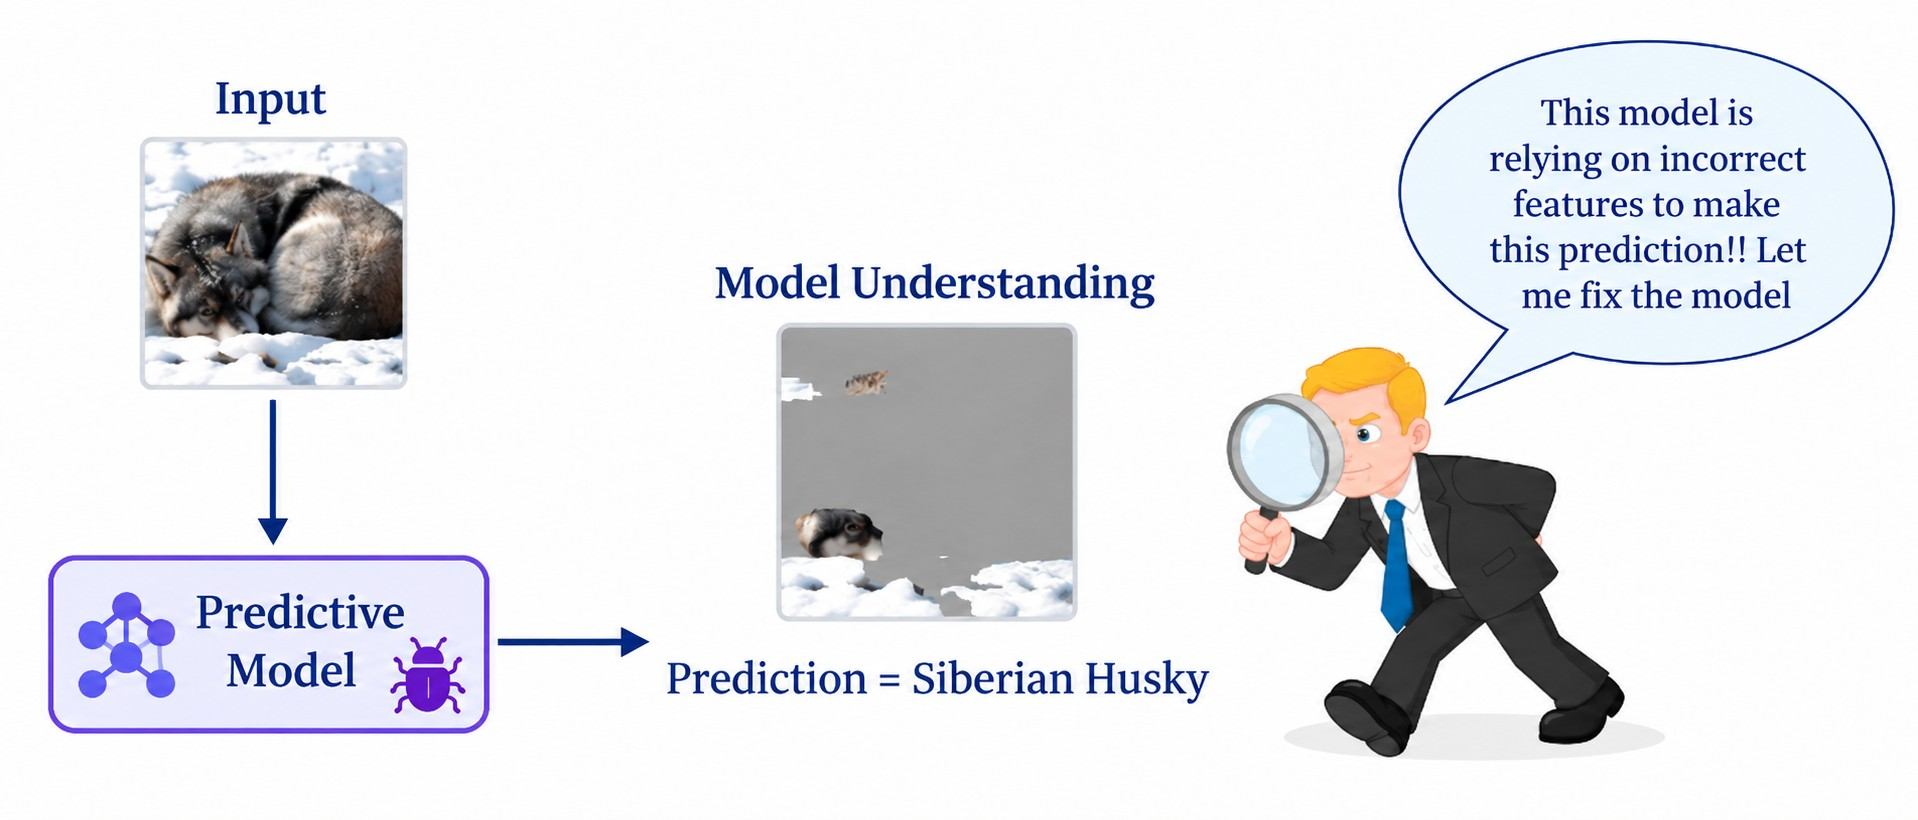

but the explanation may show that the model appears to rely heavily on **snow in the background** rather than on features of the dog itself.

This may indicate **shortcut learning** and suggests that the model or dataset should be investigated further.

A careful interpretation is:

> **The explanation provides evidence of model behaviour that deserves further investigation.**

It is usually too strong to say:

> **The explanation proves the model is wrong.**

An explanation is therefore useful as a **diagnostic tool**, but it is not definitive proof of model error.

## 4.2 Investigating potential bias

Explanations may help reveal whether a model appears to rely strongly on:

- sensitive attributes;
- proxy variables;
- features whose influence differs across groups.

This can motivate further questions such as:

- Do explanation patterns differ across groups?
- Does the model rely heavily on sensitive variables or plausible proxies?
- Are prediction errors different across subgroups?
- Are some groups affected differently by the model's decisions?

In this example, XAI helps us understand why the model predicts that the defendant is risky to release. The explanation shows that race and gender have a strong influence on the prediction, which can alert us to a possible fairness concern or source of bias.

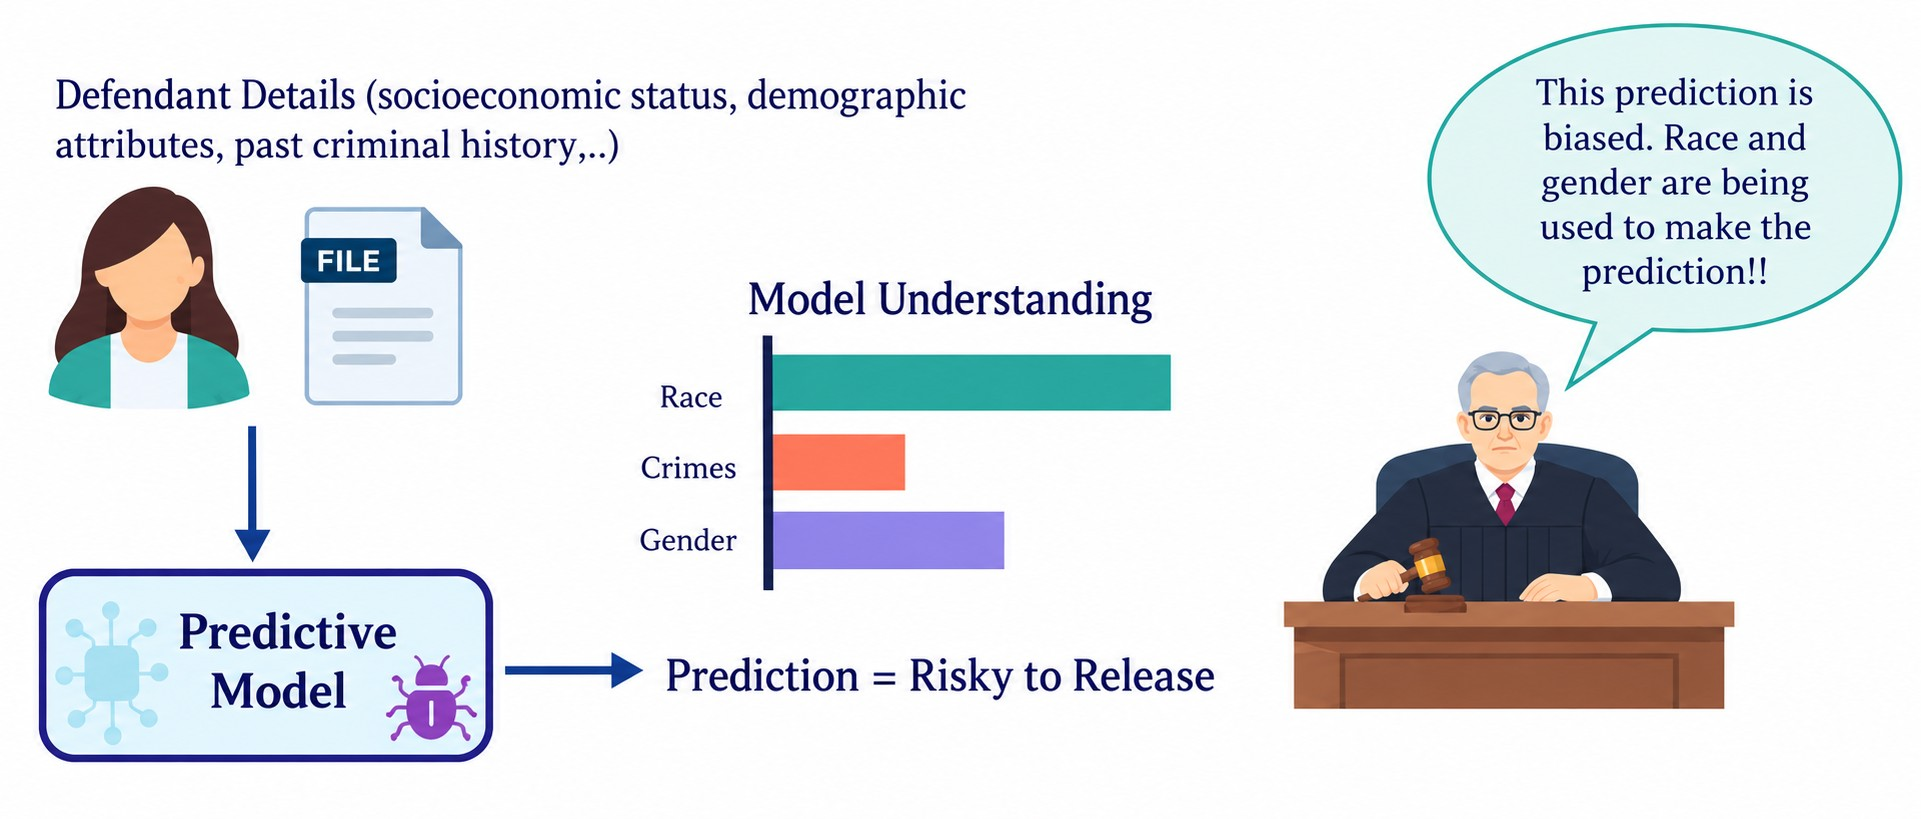

However:

> **Explainability alone does not establish whether a system is fair or biased.**

Fairness requires its own:

- definitions;
- measurements;
- subgroup analyses;
- application-specific evaluation.

An explanation can therefore provide **evidence that motivates a fairness investigation**, but it should not be treated as proof of unfairness or as a fairness certificate.

## 4.3 Recourse

When a model produces an unfavourable decision, an affected individual may want to know:

> **What feasible actions could I take to obtain a more favourable model outcome in the future?**

This idea is known as **algorithmic recourse**.

For example, after a loan application is rejected, potentially actionable changes might include:

- reducing outstanding debt;
- improving recent payment history;
- increasing stable income.

Recourse is closely related to **counterfactual explanations**, but they are not exactly the same.

A **counterfactual explanation** may describe:

> **What would need to be different for the model's prediction to change?**

Algorithmic recourse focuses more strongly on:

> **What realistic and actionable steps could the affected individual take?**

For example:

**Counterfactual statement**

> If your outstanding debt were lower, the model would predict approval.

**Recourse-oriented question**

> Is reducing the debt realistic, feasible, and sufficient to change the model's decision?

Not every suggested change provides meaningful recourse.

For example:

- changing age is impossible;
- changing an immutable or protected attribute is not actionable;
- changing a feature may be technically possible but financially unrealistic;
- changing one feature may require changes to other related variables.

Useful recourse should therefore consider:

- actionability;
- feasibility;
- cost;
- constraints;
- dependencies between variables;
- whether the recommended action is likely to change the model's output in the intended way.

> **Recourse should represent realistic actions available to the individual, rather than arbitrary feature changes.**

A change that improves the model's prediction may still have a different effect in the real world.

## 4.4 Supporting human oversight

Explanations can help humans identify whether a model appears to rely on questionable information.

Examples might include:

- an identifier that should not influence the prediction;
- a background artefact in an image;
- a clinically implausible signal;
- an unexpected part of a time series;
- a variable that a domain expert would not expect to be important.

For example, if a medical prediction model appears to rely heavily on a **patient ID**, a clinician or ML engineer may want to investigate the dataset and model before relying on the prediction.

Explanations can therefore support:

- model review;
- error investigation;
- domain-expert assessment;
- human oversight;
- decisions about whether additional evidence is needed.

It is more precise to say that explanations can support **appropriate reliance** on model outputs than to say that explanations automatically create trust.

> **An explanation can inform human judgement, but it does not guarantee that the model is correct, safe, fair, or trustworthy.**


# 5. Who needs explanations?

Different stakeholders may require different types of explanations because they interact with AI systems for different purposes.


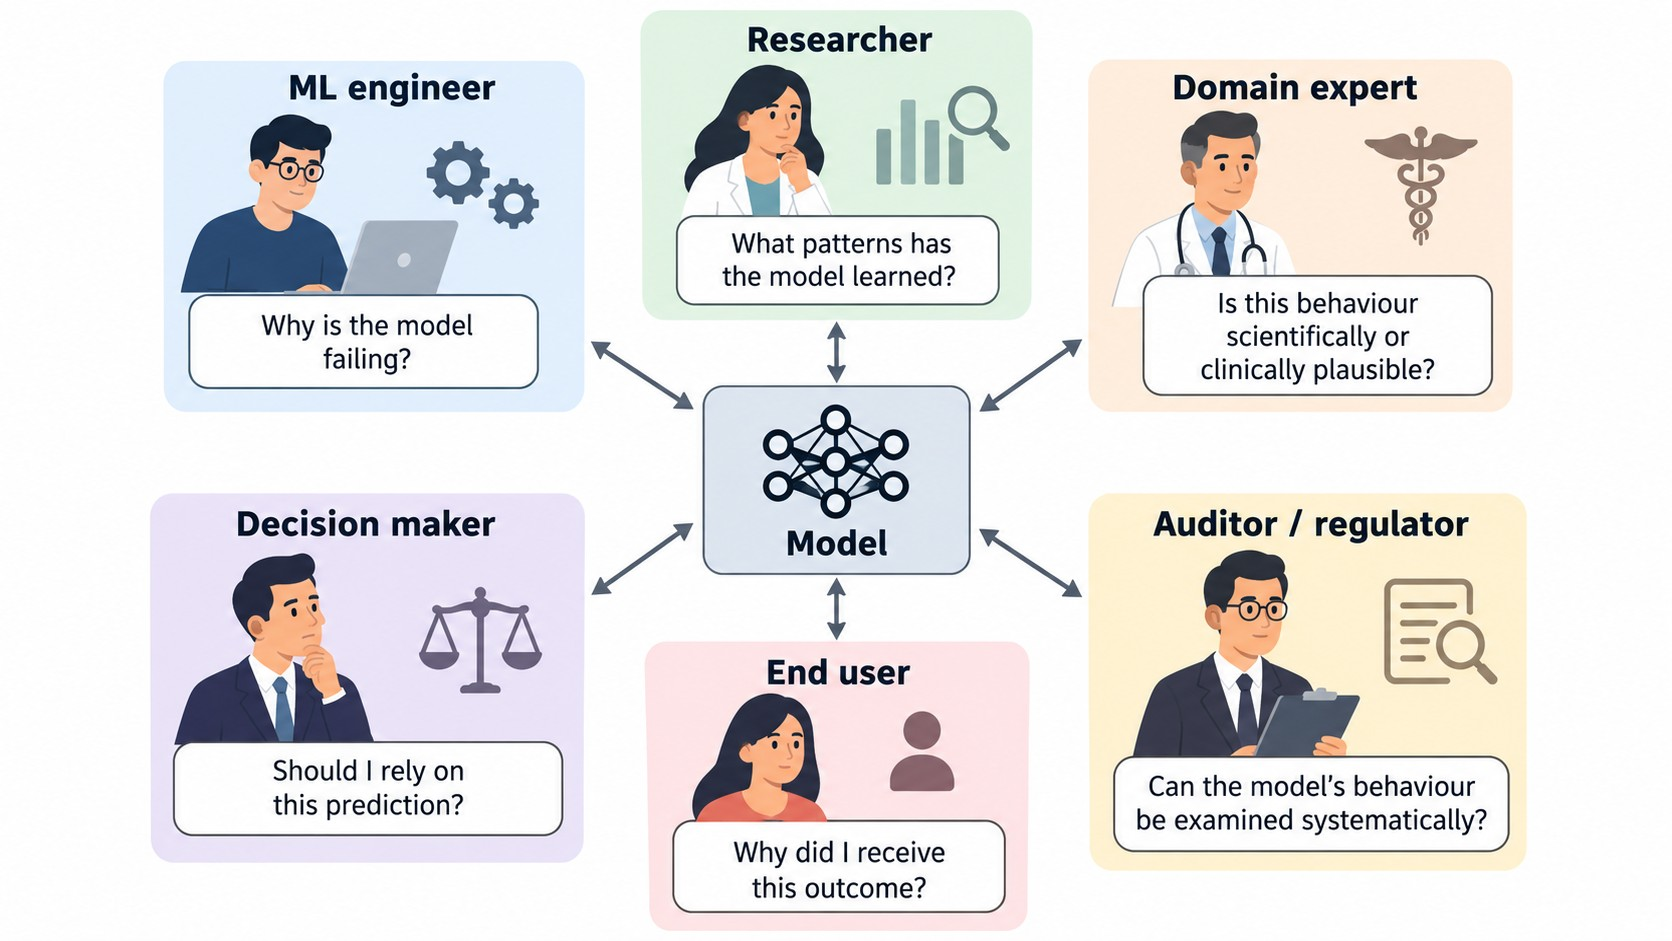

The important point is that an explanation should be designed around the **needs of the intended user**.

For example, one stakeholder may want to:

- debug a model;
- assess whether a prediction is plausible;
- understand why a decision was made;
- review whether the system behaves appropriately;
- decide whether additional investigation is needed.

This means that explanation quality is partly **context-dependent**.

A useful explanation should therefore consider:

- **who** will receive the explanation;
- **what** they need to understand;
- **why** they need the explanation;
- **what action or decision** the explanation is intended to support.

> **There is no universally best explanation.**

An explanation that is useful for an ML engineer may not be suitable for a doctor, end user, or regulator.


The goal of XAI is not simply to generate an explanation.

The explanation should be **appropriate for the stakeholder, task, and decision context**.


# 6. Interpretability vs. explainability

The terms **interpretability** and **explainability** are used somewhat differently across the literature, so in this course we use clear working definitions.

## Interpretability

**Interpretability** refers to how easily a human can understand a model's structure, components, or decision process directly.

Examples include:

- a small decision tree;
- a sparse linear model;
- logistic regression with a manageable number of features;
- a compact rule-based model.

For example, in a small decision tree, we can follow the exact sequence of decision rules used to produce a particular prediction.

In this case, much of the model behaviour can be understood directly from the model itself.

## Explainability

**Explainability** is a broader concept referring to methods or processes that help humans understand a model's behaviour or predictions.

This becomes particularly useful when the model is difficult to interpret directly.

Examples of explanation methods include:

- SHAP;
- LIME;
- Grad-CAM;
- Integrated Gradients.

Many commonly used explanation methods are applied **after the model has been trained** and are therefore described as **post-hoc explanation methods**.

The basic distinction can be illustrated as:

**Intrinsically interpretable model**  
→ the model itself can be inspected and understood directly.

**Difficult-to-interpret model + explanation method**  
→ an additional method is used to provide insight into the model's behaviour.

For example:

**Small decision tree**  
→ we can inspect its structure and follow the decision rules directly.

**Deep neural network + Grad-CAM**  
→ the neural network is difficult to inspect directly, so Grad-CAM can be used to investigate which image regions are relevant to a selected prediction.

The distinction between interpretability and explainability is not always absolute.

Interpretability depends on the **specific model and its complexity**.

For example, a decision tree with only a few nodes may be easy to understand, while a tree containing thousands of nodes may be difficult to interpret in practice.

It is therefore useful to think of interpretability as a **property that can vary in degree**, rather than as a simple yes/no property.

Similarly, an explanation does not automatically provide a complete or faithful description of everything happening inside a complex model. Different explanation methods reveal different aspects of model behaviour.

# 7. What exactly are we explaining?

Before selecting an XAI method, we first need to decide **what we want to understand**.

Different explanation methods answer different questions.

For example, we may want to explain:

- the overall behaviour of a model;
- one individual prediction;
- the influence or relevance of particular input features;
- important regions of an image;
- important time points or intervals in a time series;
- the decision rules used by a model;
- how predictions change when the input changes.

These are different **explanation targets**.

For example:

**Whole model**

> Which features are generally important across many predictions?

This requires a more **global** view of model behaviour.

**Individual prediction**

> Why was this particular loan application rejected?

This requires a **local** explanation.

**Image model**

> Which parts of this image were most relevant to the predicted class?

An image-based attribution method may be appropriate.

**Time-series model**

> Which time intervals or sensor measurements were most relevant to this prediction?

A temporal attribution method may be more suitable.

The choice of explanation therefore depends on the question we are trying to answer.

Before selecting an XAI method, we should ask:

> **What do we want to explain?**

> **Who needs the explanation?**

> **What will the explanation be used for?**

A method that is useful for understanding the overall behaviour of a model may not be suitable for explaining one individual prediction.

Similarly, a method designed for tabular data may not be appropriate for image or time-series models.

The choice of XAI method should therefore match the **explanation target, model, data type, stakeholder, and intended use**.

# 8. Taxonomy of XAI methods

A useful introductory taxonomy of XAI methods has three complementary dimensions:

1. **Intrinsic vs. post-hoc**
2. **Global vs. local**
3. **Model-specific vs. model-agnostic**

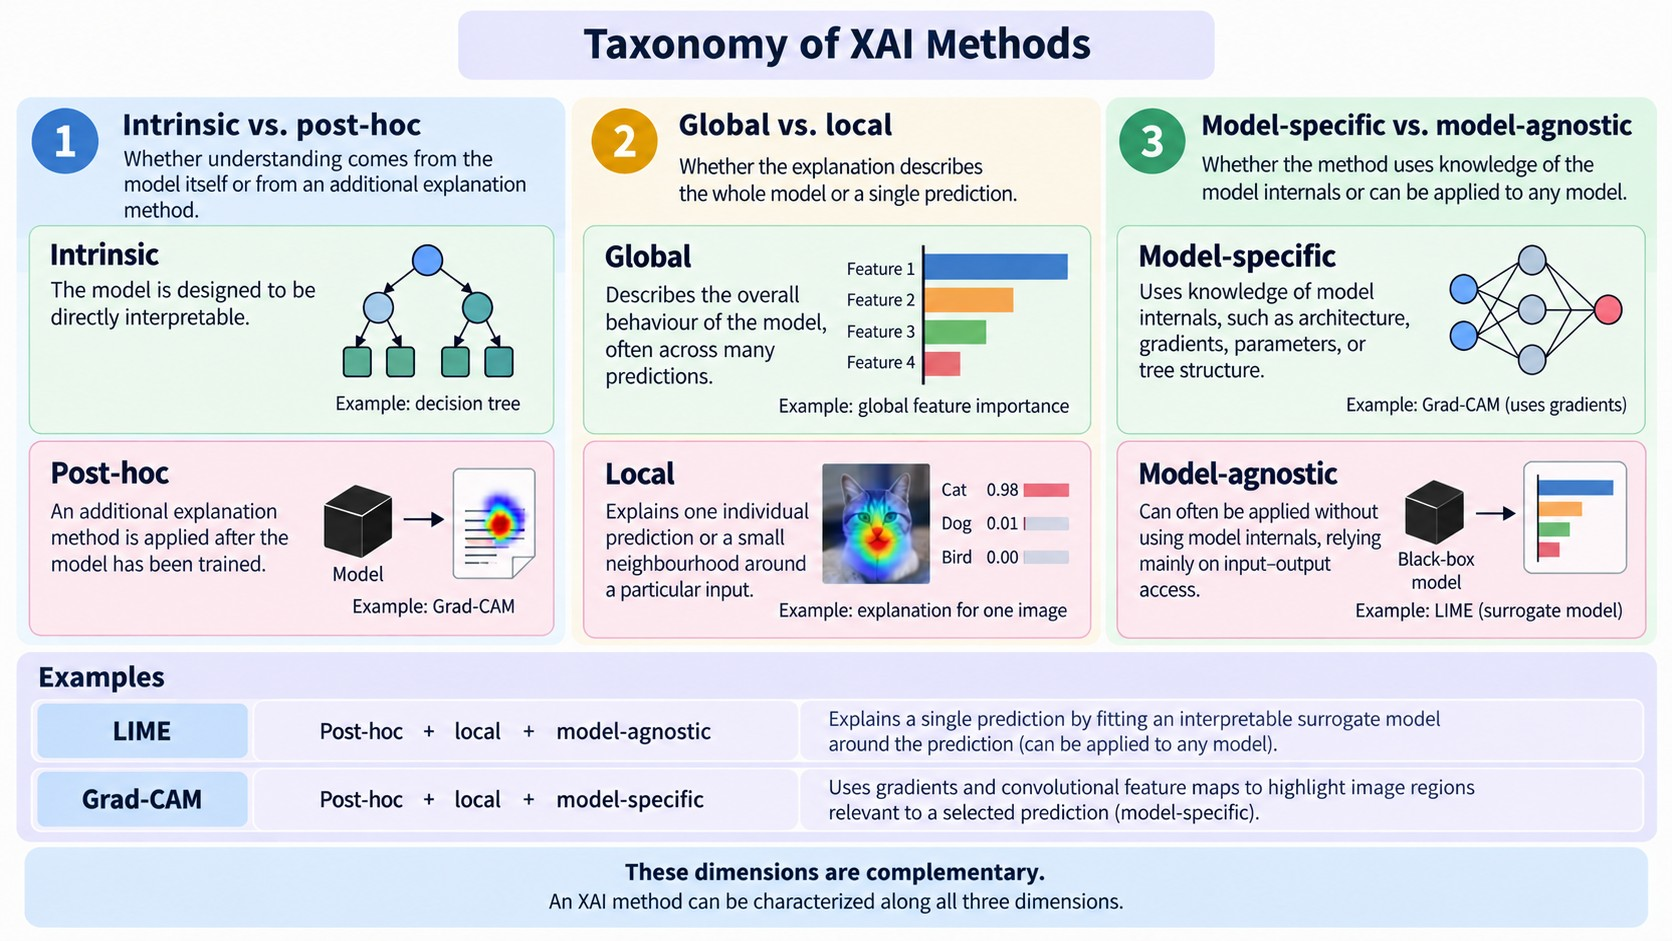

Each dimension describes a different property of an explanation approach.

An explanation approach can often be characterized along these three dimensions.

For example:

- **LIME** → post-hoc + local + model-agnostic
- **Grad-CAM** → post-hoc + local + model-specific


# 9. Intrinsic interpretability vs. post-hoc explainability

One way to distinguish XAI approaches is by asking:

> **Does understanding come directly from the model itself, or do we need an additional explanation method?**

## 9.1 Intrinsic interpretability

**Intrinsic interpretability** refers to models whose structure is relatively understandable through direct inspection.

> **The model itself is structured so that relevant aspects of its behaviour can be understood relatively directly.**

This is sometimes also called **ante-hoc interpretability**.

Examples include:

- small decision trees;
- sparse linear models;
- logistic regression with a manageable number of meaningful features;
- compact rule-based models.

For example, in a small decision tree, we can follow the sequence of decision rules used to produce a prediction:

    Age < 30?
       |
       ├── Yes → Income > 500,000?
       |             |
       |             ├── Yes → Approve
       |             └── No  → Reject
       |
       └── No → ...

For a particular individual, the path through the tree provides an **exact description of the decision rules used by that tree for that prediction**.

Because the model structure itself can be inspected, a separate explanation method may not be necessary.

### Important qualification

A model family is not automatically interpretable in every practical instance.

For example:

**Decision tree with depth 3**  
→ relatively easy to inspect.

**Decision tree with thousands of nodes**  
→ difficult to understand as a whole.

Similarly, a linear or logistic regression model with a small number of meaningful features may be relatively easy to interpret, while a model containing thousands of transformed or interacting features may be much harder to understand in practice.

> **Interpretability depends partly on the complexity and representation of the particular model, not only on the model family.**

## 9.2 Post-hoc explainability

When a trained model is difficult to interpret directly, an additional explanation procedure can be applied to investigate its behaviour or predictions.

This is known as **post-hoc explainability**.

Examples include:

- permutation importance;
- LIME;
- SHAP;
- Grad-CAM;
- Integrated Gradients.

The predictive model itself does not necessarily become intrinsically interpretable. Instead, the post-hoc method provides additional information about particular aspects of its behaviour.

For example:

**Deep neural network**

    Image → Neural network → Prediction: Husky

A method such as **Grad-CAM** can then be used to investigate which convolutional feature-map regions are relevant to the selected prediction.

Similarly:

**Complex classifier + LIME**  
→ LIME constructs a simple local surrogate around a particular input to investigate that prediction.

**Predictive model + permutation importance**  
→ permutation importance investigates how predictive performance changes when individual features are shuffled.

**Model + SHAP**  
→ SHAP can provide feature attributions for individual predictions, depending on the explainer and explanation setup.

**Differentiable model + Integrated Gradients**  
→ Integrated Gradients attributes a selected model output to input features relative to a chosen baseline.

## 9.3 Intrinsic and post-hoc approaches

| Intrinsic interpretability | Post-hoc explainability |
|---|---|
| Understanding comes largely from inspecting the model itself | An additional method is used to investigate model behaviour |
| Interpretability is supported by the model's structure or design | Explanation is produced for an already trained predictive model |
| Often associated with relatively simple or constrained models | Often used for models that are difficult to inspect directly |
| Example: small decision tree | Example: neural network + Grad-CAM |
| Example: sparse linear model | Example: classifier + LIME |

The main distinction is therefore:

**Intrinsic interpretability**

> **The model itself is designed so that relevant aspects of its behaviour can be understood relatively directly.**

**Post-hoc explainability**

> **An additional method is applied after training to investigate aspects of the model's behaviour or predictions.**

Post-hoc explanations provide information about the model, but they do not automatically make the underlying model intrinsically interpretable.



# 10. Global vs. local explanations

Global and local explanations differ mainly in the **scope of model behaviour they aim to describe**.

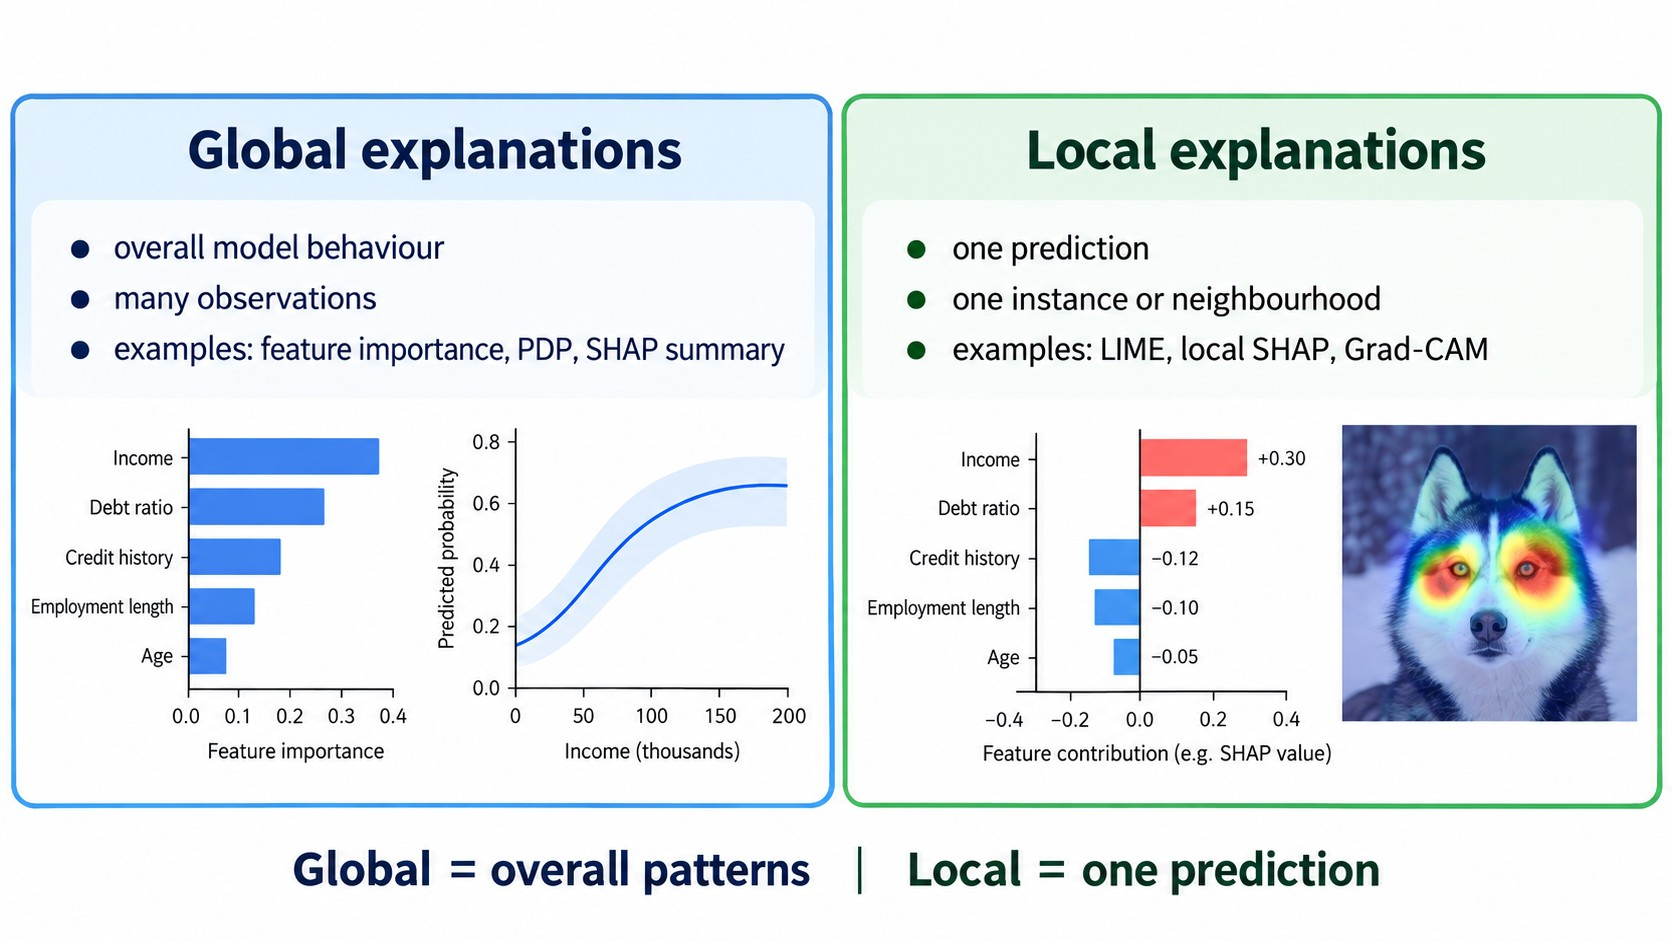

## 10.1 Global explanations

A **global explanation** aims to summarize how the model behaves overall, usually across many observations.

Typical questions include:

> Which features are generally important?

> What patterns does the model use across the dataset?

> How does the model's average prediction vary as a feature is varied under the chosen analysis setup?

Examples include:

- global feature importance;
- aggregated SHAP summaries;
- partial dependence plots;
- inspection of compact model structure.

Global explanations are useful when we want to understand the model's **overall behaviour**, rather than one specific prediction.

## 10.2 Local explanations

A **local explanation** focuses on one particular prediction, or sometimes on model behaviour in a small region around a specific input.

Typical questions include:

> Which features or input components appear relevant to this particular prediction?

> How does the explanation method characterise this specific prediction?

Examples include:

- LIME;
- local SHAP values;
- Grad-CAM;
- Integrated Gradients;
- counterfactual explanations;
- the decision path for one prediction in a decision tree.

For example:

**Global question**

> Which features are generally important when predicting loan approval?

**Local question**

> Which factors appear relevant to this particular applicant's rejected loan prediction?

A local explanation describes behaviour for a specific case and should not automatically be generalised to the entire model.

> **Local explanations provide insight into individual predictions, while global explanations summarise broader model behaviour.**


# 11. Model-specific vs. model-agnostic methods

This dimension asks whether an explanation method depends on the **internal structure of a particular model** or can work mainly through the model's input-output behaviour.

## 11.1 Model-specific methods

A **model-specific** explanation method uses information about the internal structure, parameters, or architecture of a particular type of model.

Examples include:

- decision paths or tree structure in decision trees;
- coefficients in linear or logistic regression;
- gradients in differentiable models;
- Grad-CAM for suitable convolutional neural networks.

Because these methods rely on particular model properties, they cannot necessarily be applied unchanged to every type of model.

For example:

**Grad-CAM**

uses gradients together with convolutional feature maps to identify image regions that are relevant to a selected prediction.

It therefore requires access to specific internal components of the neural network.

## 11.2 Model-agnostic methods

A **model-agnostic** explanation method does not require detailed knowledge of a model's internal architecture.

Instead, it can often treat the model mainly as a prediction function:

**Input → Model → Output**

Many model-agnostic methods investigate model behaviour by modifying, perturbing, masking, or otherwise querying the inputs and observing the resulting outputs.

Examples include:

- LIME;
- permutation importance;
- Kernel SHAP.

Because these methods do not depend on a specific internal model structure, the same general approach can often be applied across different model families, provided that predictions can be obtained from the model.

For example, permutation importance can be applied to:

- decision trees;
- Random Forests;
- neural networks;
- linear models;
- other predictive models.

## 11.3 SHAP clarification

It is important not to classify **all SHAP methods** simply as model-specific or model-agnostic.

SHAP is a broader framework that includes different explanation algorithms.

For example:

**TreeExplainer**  
→ specialised for tree-based models.

**KernelExplainer**  
→ model-agnostic and works mainly through repeated evaluations of the model's input-output behaviour.

Therefore, whether a SHAP explanation is model-specific or model-agnostic depends on the **particular SHAP explainer or algorithm being used**.

## 11.4 Simple distinction

| Model-specific | Model-agnostic |
|---|---|
| Uses information about model internals | Does not require detailed knowledge of model internals |
| Often designed for particular architectures or model families | Can often be applied across different model families |
| May use gradients, coefficients, layers, or tree structure | Often relies mainly on input-output behaviour |
| Example: Grad-CAM | Example: LIME |
| Example: decision-tree path | Example: permutation importance |

The main distinction is:

**Model-specific**

> Uses properties of the model's internal structure.

**Model-agnostic**

> Can often explain model behaviour without depending on a particular internal architecture.

# 12. Example XAI taxonomy

The three dimensions can be combined to describe different XAI approaches.

| Method | Intrinsic / post-hoc | Scope | Model relationship |
|---|---|---|---|
| Small decision tree | Intrinsic | Global + local | Direct / model-specific interpretation |
| Simple or sparse linear / logistic regression | Intrinsic | Primarily global; local contributions can also be derived | Direct / model-specific interpretation |
| Permutation importance | Post-hoc | Primarily global | Model-agnostic |
| LIME | Post-hoc | Local | Model-agnostic |
| SHAP | Post-hoc | Local; can be aggregated for global summaries | Depends on the explainer |
| Grad-CAM | Post-hoc | Local | Model-specific |
| Integrated Gradients | Post-hoc | Local | Model-specific |

A few points are important when interpreting this table:

- **Small decision trees** can provide both global understanding of the tree structure and local understanding through the decision path for one instance.
- **Simple or sparse linear and logistic regression models** are often interpreted globally through their coefficients, although instance-level contributions can also be derived from the model's decision function. Their interpretability depends on the feature representation, transformations, scale, and overall model complexity.
- **Permutation importance** is commonly used to summarise how predictive performance changes when individual features are shuffled across an evaluation dataset.
- **LIME** explains a particular prediction by fitting a simple local surrogate model around that instance.
- **SHAP** typically provides feature-attribution values for individual predictions. These local attributions can be aggregated across observations to obtain broader global summaries.
- **Grad-CAM** provides a local explanation for a selected prediction using gradients together with convolutional feature maps.
- **Integrated Gradients** attributes a selected model output to input features relative to a chosen baseline and requires access to model gradients.

The same explanation approach can therefore be characterised along several dimensions at the same time.

For intrinsically interpretable models, such as a small decision tree or a simple sparse linear model, understanding often comes from **direct inspection of the model itself** rather than from applying a separate post-hoc explanation method.

# 13. Explanation does not mean causality

XAI methods typically explain **model behaviour**, not real-world causal relationships.

Suppose SHAP assigns a large attribution to `age`.

A more precise interpretation is:

> **Age received a large SHAP attribution for this prediction under the chosen explainer, model output, and background/reference setup.**

This means that `age` had a large attribution to the explained model output under that SHAP analysis.

It does **not** mean:

> **Age causes the real-world outcome.**

Therefore:

**Feature attribution ≠ causal effect**

A feature may receive a large attribution because it is:

- strongly associated with the prediction;
- correlated with other predictive variables;
- acting as a proxy for another variable;
- affected by the background or reference distribution used by the explanation method.

Predictive explanation and causal inference answer different questions.

**Predictive explanation asks:**

> Which input features appear relevant to the model's prediction, according to the selected explanation method?

**Causal inference asks:**

> What would happen to the real-world outcome if we intervened and changed a variable?

These questions should not be confused.

> **An explanation of model behaviour does not by itself establish real-world causation.**

# 14. Explainability does not guarantee trustworthiness

Explainability can be useful, but it should not be confused with other desirable properties of an AI system.

An explanation may help us investigate how a model behaves, but it does not automatically establish that the model is:

- correct;
- fair;
- robust;
- safe;
- trustworthy.

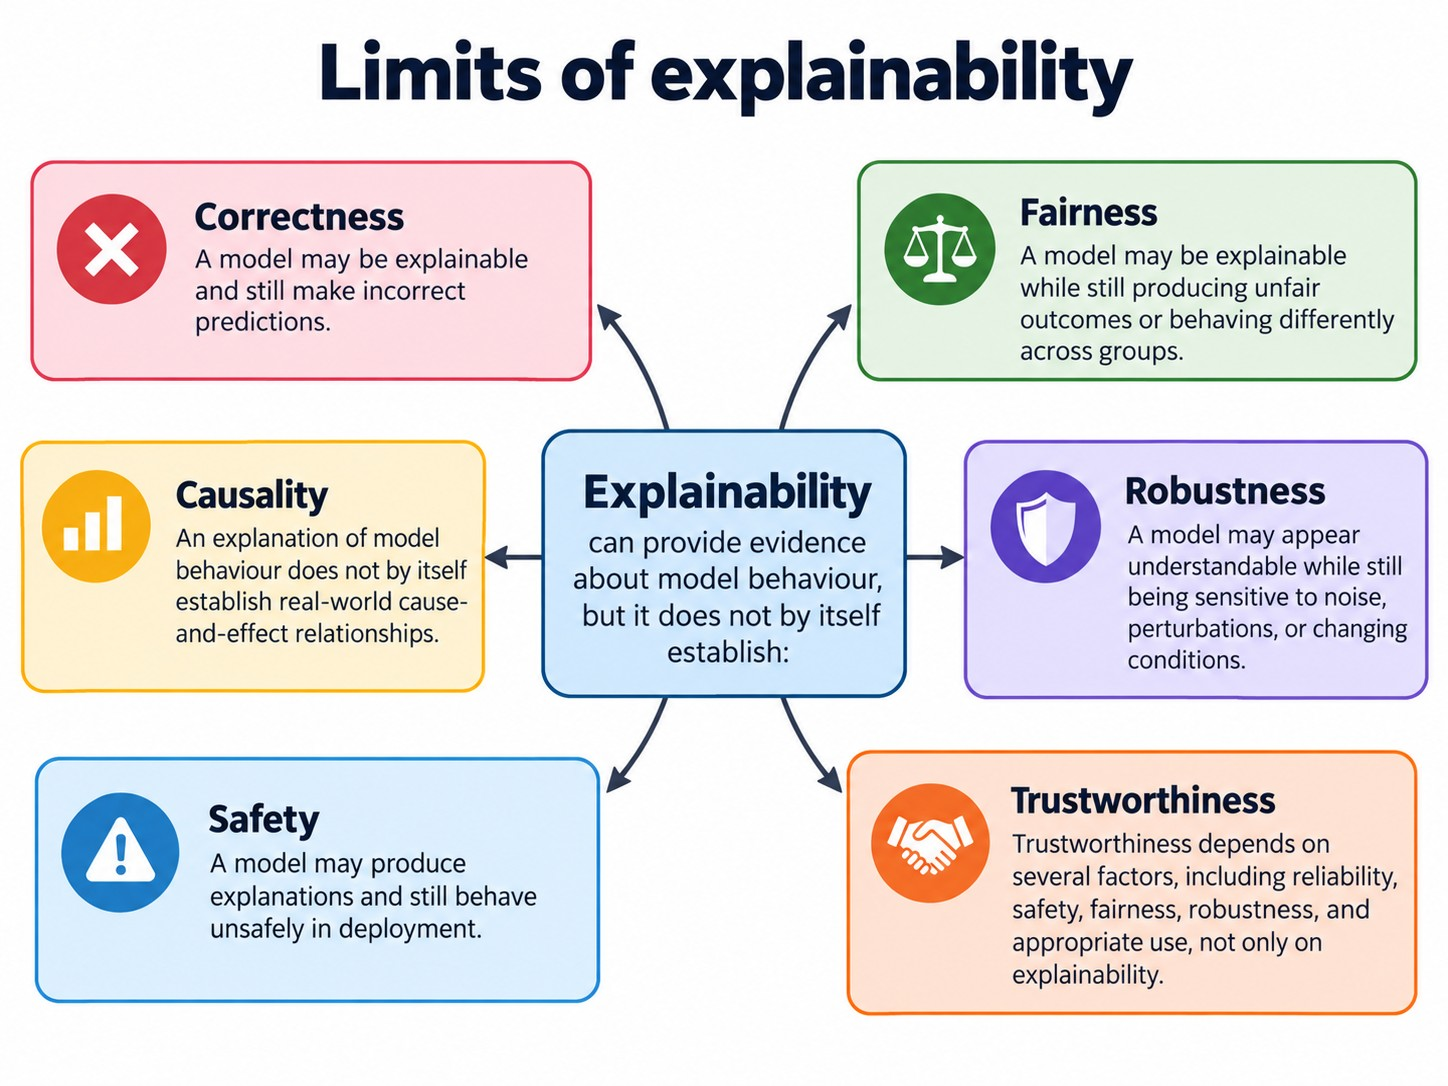

These distinctions are important:

**Explainable ≠ Correct**  
A model may provide a clear explanation and still make an incorrect prediction.

**Explainable ≠ Fair**  
A model may be explainable while still producing unfair outcomes or exhibiting group disparities that require fairness evaluation.

**Explainable ≠ Robust**  
A model may be understandable while still being sensitive to noise, perturbations, or changing conditions.

**Feature attribution ≠ Causal effect**  
An explanation of model behaviour does not by itself establish real-world cause-and-effect relationships.

**Explainable ≠ Safe**  
A model may produce explanations and still behave unsafely in deployment.

**Explainable ≠ Trustworthy**  
Trustworthiness depends on several factors, including reliability, safety, fairness, robustness, and appropriate use, rather than on explainability alone.

Explanations can therefore support the investigation of these properties, but they do not establish them automatically.

> **Explainability can provide evidence about model behaviour, while trustworthiness requires broader evaluation.**

# 15. What makes a good explanation?

We study explanation quality in more depth in Week 3.

For now, consider four useful questions.

### Faithfulness

Does the explanation accurately reflect the behaviour of the **model being explained**?

A faithful explanation should capture relevant aspects of the patterns or dependencies the model actually uses.

### Stability

Do small, non-semantic changes to the input produce reasonably similar explanations when the model's behaviour is also similar?

Large changes in an explanation under small, non-semantic perturbations, while model behaviour remains similar, may indicate **instability**.

### Understandability

Can the intended user understand the explanation?

The appropriate level of detail may differ for:

- ML engineers;
- domain experts;
- decision makers;
- end users.

### Usefulness

Does the explanation help the user perform the intended task?

For example, an explanation may be useful for:

- debugging;
- investigating possible bias;
- supporting recourse;
- reviewing an individual prediction;
- deciding whether further investigation is needed.

These properties are related, but they are not equivalent.

> **An explanation can be easy to understand but still be unfaithful to the model.**

Similarly, an explanation can be faithful to the model but difficult for a particular user to interpret.

These four properties are useful starting points, but they are **not an exhaustive set of evaluation criteria**. We will examine explanation evaluation in more depth in Week 3.

The quality of an explanation therefore depends not only on the explanation method itself, but also on the **model, task, stakeholder, and intended use**.

# 16. Breakout group activity — 15 minutes

## Balancing predictive performance and interpretability

Choose one application domain:

- healthcare;
- finance;
- autonomous vehicles;
- hiring;
- Earth observation;
- energy systems.

Discuss the following questions:

1. Should predictive performance always be the main objective in this domain?
2. In which situations is interpretability especially important?
3. What risks can arise when a difficult-to-interpret model is used?
4. Can an interpretable model still produce harmful or inappropriate decisions?
5. Can a highly accurate model still be unsuitable for deployment?
6. Who needs the explanation in this setting: developer, domain expert, decision maker, end user, auditor, or regulator?
7. What would make the explanation useful for that stakeholder?
8. Under what conditions would you choose a simpler interpretable model rather than a more complex model with post-hoc explanations?

### Group output

Prepare a short summary covering:

- the chosen domain;
- the main risk you identified;
- who needs the explanation;
- what kind of explanation would be most useful;
- whether interpretability should influence model choice in this setting.

# 17. Python Exercise Notebooks

The practical work is separated topic-by-topic while using the same Titanic dataset throughout.

1. 01_decision_trees_intrinsic_interpretability.ipynb

   Direct inspection of a small decision tree, exact decision paths, complexity, and stability.

2. 02_feature_importance.ipynb

   Global impurity-based feature importance and its limitations.

3. 03_intrinsic_vs_posthoc_explainability.ipynb

   Intrinsic interpretation of a small tree compared with post-hoc Tree SHAP for a Random Forest.

4. 04_global_vs_local_explanations.ipynb

   Global SHAP summaries compared with local explanations for individual predictions.

SHAP is used here only to make the Week 1 taxonomy concrete. Detailed SHAP methodology is introduced in the next lecture.


# 18. Quick classification exercise

For each example, classify it using the three dimensions:

- intrinsic or post-hoc?
- global or local?
- model-specific or model-agnostic?

### A. A doctor inspects a small decision tree

### B. LIME explains one rejected loan application

### C. Permutation importance is computed for a Random Forest

### D. Grad-CAM highlights image regions relevant to a CNN prediction

### E. Logistic-regression coefficients are inspected



## Answers

| Example | Classification |
|---|---|
| A. Small decision tree | Intrinsic + global/local + direct/model-specific interpretation |
| B. LIME | Post-hoc + local + model-agnostic |
| C. Permutation importance | Post-hoc + primarily global + model-agnostic |
| D. Grad-CAM | Post-hoc + local + model-specific |
| E. Logistic-regression coefficients | Intrinsic + primarily global + direct/model-specific interpretation |

> Here we assume that the logistic-regression model has a manageable number of meaningful features. Interpretability can decrease substantially when the feature representation is very large, heavily transformed, or difficult to interpret.

# 19. Common misconceptions

**High predictive performance means the model is trustworthy.**  
→ Not necessarily. Strong performance on an evaluation dataset does not guarantee fairness, robustness, safety, or reliable behaviour after deployment.

**If a model is interpretable, it must be correct.**  
→ No. A model can be easy to understand and still make incorrect predictions or rely on inappropriate assumptions.

**A feature with high importance causes the outcome.**  
→ No. Feature importance or attribution describes model behaviour, not necessarily real-world causation.

**A visually convincing explanation must be faithful.**  
→ No. An explanation can look plausible or intuitive while still failing to reflect the model's actual behaviour accurately.

**One local explanation describes the whole model.**  
→ No. A local explanation describes one prediction, or a small region around it, and should not automatically be generalized to the entire model.

**All SHAP methods are model-agnostic.**  
→ No. SHAP is a framework containing different explainers. Some are specialized for particular model families, while others are model-agnostic.

**Explainability automatically creates trust.**  
→ No. Explanations can support appropriate human reliance, but trustworthiness requires broader evaluation of properties such as reliability, fairness, robustness, and safety.

# 20. Summary

This week, we moved from focusing only on:

**Prediction**

toward:

**Prediction + investigation of model behaviour**

We discussed why model understanding becomes especially important in settings where:

- decisions have serious consequences;
- deployment conditions may differ from development data;
- important criteria such as safety, fairness, and reliability are difficult to capture fully with predictive metrics alone.

The three main taxonomy dimensions were:

**Intrinsic ↔ Post-hoc**

**Global ↔ Local**

**Model-specific ↔ Model-agnostic**

We also saw that different explanation methods answer different questions and should be chosen according to:

- what we want to explain;
- who needs the explanation;
- the model and data type;
- the intended use of the explanation.

Important cautions:

**Feature attribution ≠ causal effect**

**Explanation ≠ correctness**

**Explanation ≠ fairness**

**Explanation ≠ robustness**

**Explanation ≠ safety**

**Explanation ≠ trustworthiness**

An explanation can provide useful evidence about model behaviour, but it does not automatically establish these properties.

The main idea is:

> **XAI helps us move beyond asking only what a model predicts toward investigating how the model behaves and what information appears to influence its predictions.**


# 21. Exit questions

Before leaving, try to answer:

1. What is the difference between **intrinsic interpretability** and **post-hoc explainability**?
2. What is the difference between **global** and **local** explanations?
3. Give one example of a **model-agnostic** explanation method.
4. Why does **feature importance or attribution not establish causality**?
5. Why might two different stakeholders need different explanations?

## Lecture 1 takeaways

- Predictive performance and model understanding answer different questions.
- XAI methods can be described as intrinsic/post-hoc, global/local, and model-specific/model-agnostic.
- Explanations should match the stakeholder, task, and intended use.
- Explanation does not automatically imply causality, fairness, correctness, safety, or trustworthiness.



# 22. Preparation for next lecture

Next week, we move from the **taxonomy of XAI methods** to specific explanation techniques.

We will study XAI methods, such as:

- SHAP;
- LIME;
- saliency maps;
- Guided Backpropagation;
- Grad-CAM;
- Integrated Gradients.

For each method, we will ask:

- How is the explanation produced?
- Is the method local or global?
- Is it model-specific or model-agnostic?
- What assumptions or design choices does it rely on?
- What are its main limitations?
- How should the resulting explanation be interpreted?
- What should we avoid concluding from the explanation?

We will also discuss when simpler, more interpretable models may be preferred and why higher predictive performance does not always imply lower interpretability.

The goal is to move from:

**What type of explanation is this?**

to:

**How is the explanation generated, and what does it tell us about the model?**

# References

- Lipton, Z. C. (2018). *The Mythos of Model Interpretability*. Queue, 16(3), 31–57.

- Doshi-Velez, F., & Kim, B. (2017). *Towards a Rigorous Science of Interpretable Machine Learning*. arXiv:1702.08608.

- Molnar, C. (2025). *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable* (3rd ed.).

- Rudin, C. (2019). *Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead*. Nature Machine Intelligence, 1, 206–215.

- Murdoch, W. J., Singh, C., Kumbier, K., Abbasi-Asl, R., & Yu, B. (2019). *Definitions, methods, and applications in interpretable machine learning*. Proceedings of the National Academy of Sciences, 116(44), 22071–22080.

- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *“Why Should I Trust You?”: Explaining the Predictions of Any Classifier*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 1135–1144.

- Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. Advances in Neural Information Processing Systems, 30.

- Selvaraju, R. R., Cogswell, M., Das, A., Vedantam, R., Parikh, D., & Batra, D. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-Based Localization*. Proceedings of the IEEE International Conference on Computer Vision (ICCV), 618–626.

- Sundararajan, M., Taly, A., & Yan, Q. (2017). *Axiomatic Attribution for Deep Networks*. Proceedings of the 34th International Conference on Machine Learning, PMLR 70, 3319–3328.

- SHAP documentation: https://shap.readthedocs.io/

> **The goal of XAI is not simply to make a model appear understandable. It is to obtain useful evidence about model behaviour, communicate that evidence appropriately to the intended stakeholder, and remain clear about what the explanation does and does not establish.**